In [1]:
# -----------------------------
# 1. Import Required Libraries
# -----------------------------

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

import matplotlib.pyplot as plt
import numpy as np

# For evaluation metrics
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

In [2]:
# -----------------------------
# 2. Set Random Seed
# -----------------------------

torch.manual_seed(42)

# Check whether GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)


Device: cpu


100%|██████████| 9.91M/9.91M [00:00<00:00, 61.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.74MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 14.4MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.84MB/s]


Number of training samples: 60000
Number of testing samples: 10000


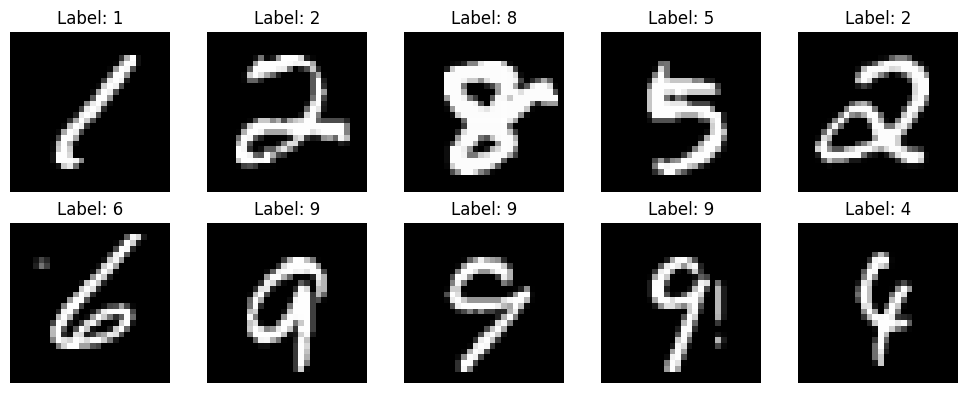

In [3]:
# ============================================================
# TASK 1: LOAD AND PREPROCESS MNIST DATASET
# ============================================================

# MNIST images are 28 x 28 grayscale images.
# Normalize pixel values approximately to [-1, 1].

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])


# Download and load training dataset
train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

# Download and load testing dataset
test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)


# Create DataLoaders
batch_size = 128

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

print("Number of training samples:", len(train_dataset))
print("Number of testing samples:", len(test_dataset))


# -----------------------------
# Display Sample MNIST Images
# -----------------------------

images, labels = next(iter(train_loader))

plt.figure(figsize=(10, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)

    # Undo normalization for visualization
    image = images[i].squeeze().numpy()

    image = image * 0.3081 + 0.1307

    plt.imshow(image, cmap="gray")
    plt.title("Label: " + str(labels[i].item()))
    plt.axis("off")

plt.tight_layout()
plt.show()


In [4]:
# ============================================================
# TASK 2: BUILD PYTORCH MODEL
# ============================================================

class MNISTModel(nn.Module):

    def __init__(self, dropout_rate=0.0):

        super(MNISTModel, self).__init__()

        self.flatten = nn.Flatten()

        self.network = nn.Sequential(

            # Input: 28 x 28 = 784
            nn.Linear(28 * 28, 256),

            nn.ReLU(),

            # Dropout regularization
            nn.Dropout(dropout_rate),

            nn.Linear(256, 128),

            nn.ReLU(),

            # Dropout regularization
            nn.Dropout(dropout_rate),

            nn.Linear(128, 10)
        )

    def forward(self, x):

        x = self.flatten(x)

        x = self.network(x)

        return x

In [5]:
# ============================================================
# TASK 3: TRAIN THE MODEL
# ============================================================

def train_model(model, optimizer, epochs=10):

    criterion = nn.CrossEntropyLoss()

    train_losses = []
    train_accuracies = []

    test_losses = []
    test_accuracies = []

    for epoch in range(epochs):

        # -------------------------
        # Training
        # -------------------------

        model.train()

        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in train_loader:

            images = images.to(device)
            labels = labels.to(device)

            # Clear gradients
            optimizer.zero_grad()

            # Forward pass
            outputs = model(images)

            # Calculate loss
            loss = criterion(outputs, labels)

            # Backpropagation
            loss.backward()

            # Update weights
            optimizer.step()

            running_loss += loss.item()

            # Calculate accuracy
            _, predicted = torch.max(outputs.data, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_loss = running_loss / len(train_loader)
        train_accuracy = 100 * correct / total


        # -------------------------
        # Testing
        # -------------------------

        model.eval()

        test_loss = 0.0
        correct = 0
        total = 0

        with torch.no_grad():

            for images, labels in test_loader:

                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)

                loss = criterion(outputs, labels)

                test_loss += loss.item()

                _, predicted = torch.max(outputs.data, 1)

                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        test_loss = test_loss / len(test_loader)

        test_accuracy = 100 * correct / total


        # Store values
        train_losses.append(train_loss)
        train_accuracies.append(train_accuracy)

        test_losses.append(test_loss)
        test_accuracies.append(test_accuracy)


        print(
            f"Epoch [{epoch+1}/{epochs}] "
            f"Train Loss: {train_loss:.4f} "
            f"Train Acc: {train_accuracy:.2f}% "
            f"Test Loss: {test_loss:.4f} "
            f"Test Acc: {test_accuracy:.2f}%"
        )

    return (
        train_losses,
        train_accuracies,
        test_losses,
        test_accuracies
    )


# ============================================================
# EXPERIMENT 1: BASELINE MODEL
# No Dropout and No L2 Regularization
# ============================================================

print("\n========================================")
print("EXPERIMENT 1: BASELINE MODEL")
print("========================================")

baseline_model = MNISTModel(dropout_rate=0.0).to(device)

baseline_optimizer = optim.Adam(
    baseline_model.parameters(),
    lr=0.001
)

baseline_history = train_model(
    baseline_model,
    baseline_optimizer,
    epochs=10
)


# ============================================================
# EXPERIMENT 2: DROPOUT REGULARIZATION
# ============================================================

print("\n========================================")
print("EXPERIMENT 2: DROPOUT REGULARIZATION")
print("========================================")

dropout_model = MNISTModel(
    dropout_rate=0.5
).to(device)

dropout_optimizer = optim.Adam(
    dropout_model.parameters(),
    lr=0.001
)

dropout_history = train_model(
    dropout_model,
    dropout_optimizer,
    epochs=10
)


# ============================================================
# EXPERIMENT 3: L2 WEIGHT DECAY
# ============================================================

print("\n========================================")
print("EXPERIMENT 3: L2 WEIGHT DECAY")
print("========================================")

l2_model = MNISTModel(
    dropout_rate=0.0
).to(device)

# weight_decay implements L2 regularization
l2_optimizer = optim.Adam(
    l2_model.parameters(),
    lr=0.001,
    weight_decay=1e-4
)

l2_history = train_model(
    l2_model,
    l2_optimizer,
    epochs=10
)




EXPERIMENT 1: BASELINE MODEL
Epoch [1/10] Train Loss: 0.2691 Train Acc: 91.88% Test Loss: 0.1310 Test Acc: 96.09%
Epoch [2/10] Train Loss: 0.1029 Train Acc: 96.81% Test Loss: 0.0906 Test Acc: 97.14%
Epoch [3/10] Train Loss: 0.0693 Train Acc: 97.84% Test Loss: 0.0848 Test Acc: 97.45%
Epoch [4/10] Train Loss: 0.0513 Train Acc: 98.32% Test Loss: 0.0754 Test Acc: 97.79%
Epoch [5/10] Train Loss: 0.0402 Train Acc: 98.68% Test Loss: 0.0708 Test Acc: 97.85%
Epoch [6/10] Train Loss: 0.0298 Train Acc: 99.02% Test Loss: 0.0736 Test Acc: 97.85%
Epoch [7/10] Train Loss: 0.0260 Train Acc: 99.13% Test Loss: 0.0751 Test Acc: 97.72%
Epoch [8/10] Train Loss: 0.0218 Train Acc: 99.28% Test Loss: 0.0688 Test Acc: 98.15%
Epoch [9/10] Train Loss: 0.0226 Train Acc: 99.25% Test Loss: 0.0786 Test Acc: 97.82%
Epoch [10/10] Train Loss: 0.0169 Train Acc: 99.42% Test Loss: 0.0913 Test Acc: 97.60%

EXPERIMENT 2: DROPOUT REGULARIZATION
Epoch [1/10] Train Loss: 0.4450 Train Acc: 86.33% Test Loss: 0.1610 Test Acc: 95.

In [6]:
# ============================================================
# TASK 4: EVALUATE MODEL USING SUITABLE METRICS
# ============================================================

def evaluate_model(model, model_name):

    model.eval()

    correct = 0
    total = 0

    all_predictions = []
    all_labels = []

    with torch.no_grad():

        for images, labels in test_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)

            correct += (predicted == labels).sum().item()

            all_predictions.extend(
                predicted.cpu().numpy()
            )

            all_labels.extend(
                labels.cpu().numpy()
            )

    accuracy = 100 * correct / total

    print("\n========================================")
    print(model_name)
    print("========================================")

    print(f"Test Accuracy: {accuracy:.2f}%")

    print("\nClassification Report:")

    print(
        classification_report(
            all_labels,
            all_predictions
        )
    )

    return accuracy, all_labels, all_predictions


# Evaluate all models

baseline_accuracy, y_true, baseline_pred = evaluate_model(
    baseline_model,
    "Baseline Model"
)

dropout_accuracy, _, dropout_pred = evaluate_model(
    dropout_model,
    "Dropout Model"
)

l2_accuracy, _, l2_pred = evaluate_model(
    l2_model,
    "L2 Weight Decay Model"
)



Baseline Model
Test Accuracy: 97.60%

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.98      0.98       980
           1       0.98      1.00      0.99      1135
           2       0.99      0.96      0.97      1032
           3       0.98      0.97      0.97      1010
           4       0.99      0.97      0.98       982
           5       0.95      0.98      0.97       892
           6       0.97      0.98      0.98       958
           7       0.97      0.98      0.98      1028
           8       0.97      0.98      0.98       974
           9       0.96      0.97      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000


Dropout Model
Test Accuracy: 97.66%

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.98       980
         

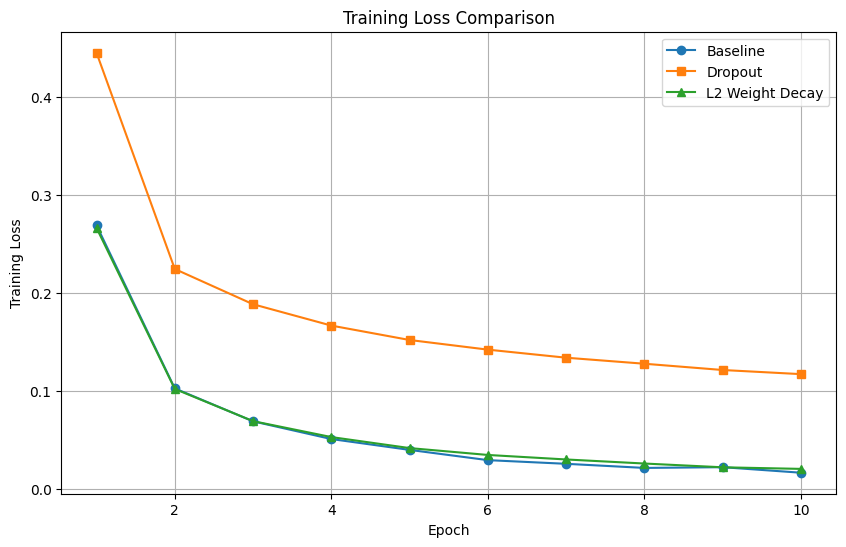

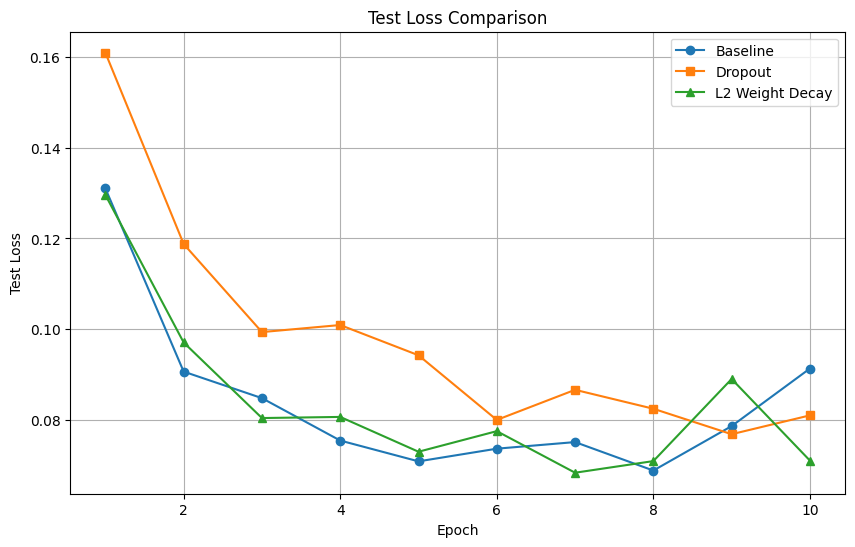

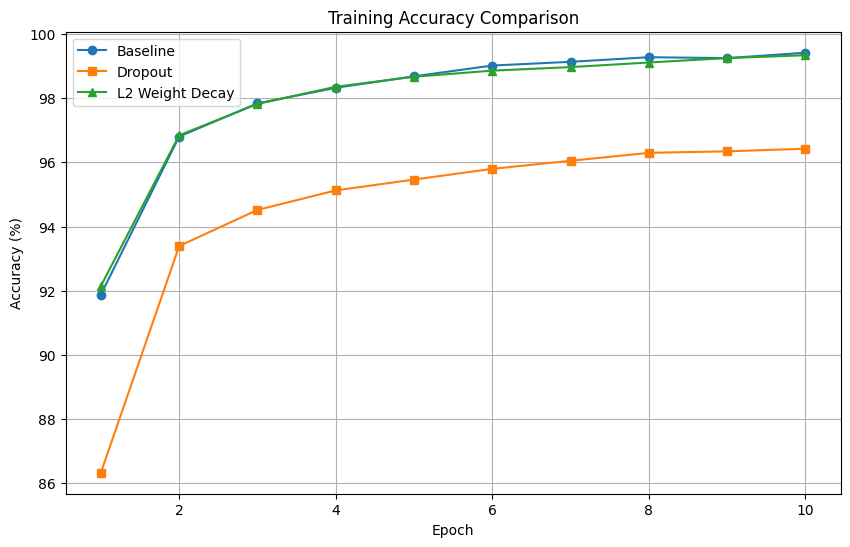

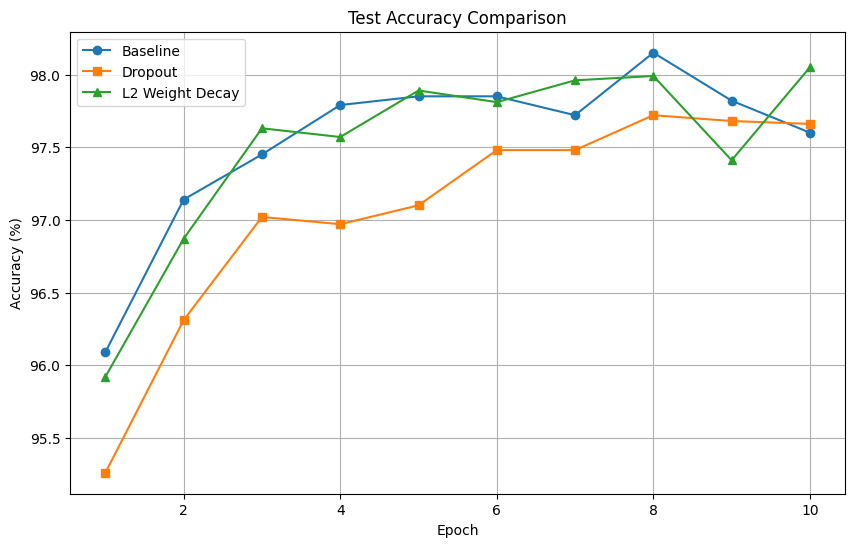

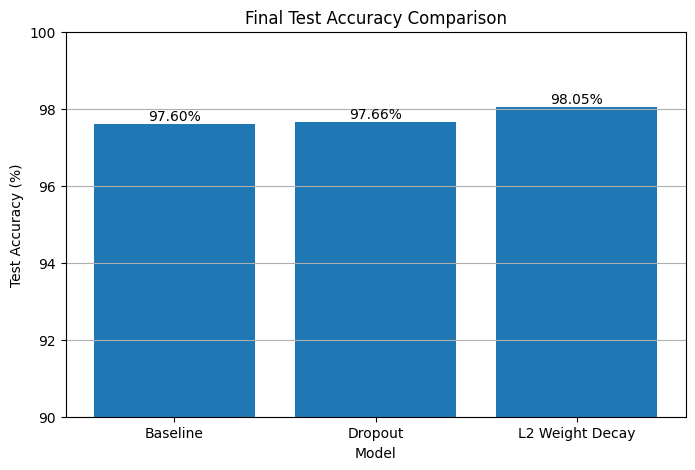

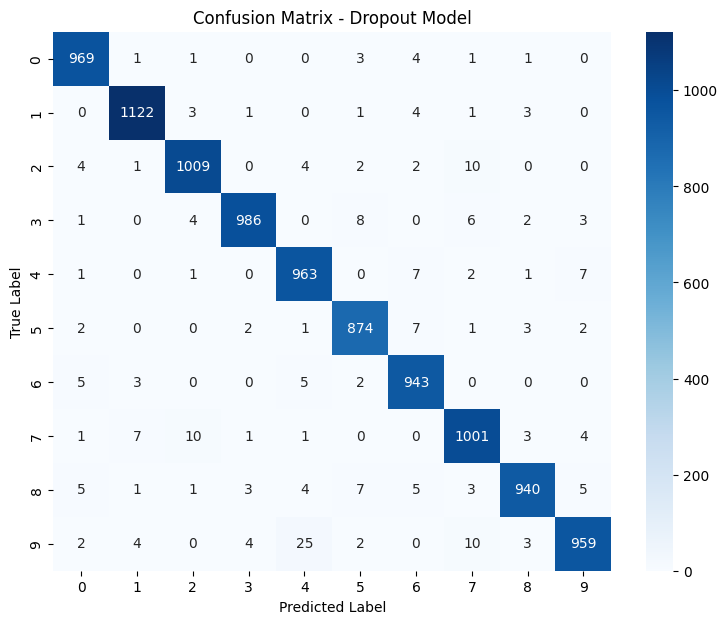

In [7]:
# ============================================================
# TASK 5: VISUALIZE TRAINING RESULTS
# ============================================================

# Extract histories

baseline_train_loss = baseline_history[0]
baseline_train_acc = baseline_history[1]
baseline_test_loss = baseline_history[2]
baseline_test_acc = baseline_history[3]

dropout_train_loss = dropout_history[0]
dropout_train_acc = dropout_history[1]
dropout_test_loss = dropout_history[2]
dropout_test_acc = dropout_history[3]

l2_train_loss = l2_history[0]
l2_train_acc = l2_history[1]
l2_test_loss = l2_history[2]
l2_test_acc = l2_history[3]


epochs = range(1, 11)


# ============================================================
# Plot 1: Training Loss Comparison
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    epochs,
    baseline_train_loss,
    marker="o",
    label="Baseline"
)

plt.plot(
    epochs,
    dropout_train_loss,
    marker="s",
    label="Dropout"
)

plt.plot(
    epochs,
    l2_train_loss,
    marker="^",
    label="L2 Weight Decay"
)

plt.xlabel("Epoch")
plt.ylabel("Training Loss")

plt.title("Training Loss Comparison")

plt.legend()
plt.grid(True)

plt.show()


# ============================================================
# Plot 2: Test Loss Comparison
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    epochs,
    baseline_test_loss,
    marker="o",
    label="Baseline"
)

plt.plot(
    epochs,
    dropout_test_loss,
    marker="s",
    label="Dropout"
)

plt.plot(
    epochs,
    l2_test_loss,
    marker="^",
    label="L2 Weight Decay"
)

plt.xlabel("Epoch")
plt.ylabel("Test Loss")

plt.title("Test Loss Comparison")

plt.legend()
plt.grid(True)

plt.show()


# ============================================================
# Plot 3: Training Accuracy Comparison
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    epochs,
    baseline_train_acc,
    marker="o",
    label="Baseline"
)

plt.plot(
    epochs,
    dropout_train_acc,
    marker="s",
    label="Dropout"
)

plt.plot(
    epochs,
    l2_train_acc,
    marker="^",
    label="L2 Weight Decay"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")

plt.title("Training Accuracy Comparison")

plt.legend()
plt.grid(True)

plt.show()


# ============================================================
# Plot 4: Test Accuracy Comparison
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    epochs,
    baseline_test_acc,
    marker="o",
    label="Baseline"
)

plt.plot(
    epochs,
    dropout_test_acc,
    marker="s",
    label="Dropout"
)

plt.plot(
    epochs,
    l2_test_acc,
    marker="^",
    label="L2 Weight Decay"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")

plt.title("Test Accuracy Comparison")

plt.legend()
plt.grid(True)

plt.show()


# ============================================================
# Plot 5: Final Accuracy Comparison
# ============================================================

model_names = [
    "Baseline",
    "Dropout",
    "L2 Weight Decay"
]

accuracies = [
    baseline_accuracy,
    dropout_accuracy,
    l2_accuracy
]

plt.figure(figsize=(8, 5))

bars = plt.bar(
    model_names,
    accuracies
)

plt.ylabel("Test Accuracy (%)")
plt.xlabel("Model")

plt.title("Final Test Accuracy Comparison")

plt.ylim(90, 100)

# Display accuracy values on bars
for bar, accuracy in zip(bars, accuracies):

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.1,
        f"{accuracy:.2f}%",
        ha="center"
    )

plt.grid(axis="y")

plt.show()


# ============================================================
# CONFUSION MATRIX FOR DROPOUT MODEL
# ============================================================

cm = confusion_matrix(
    y_true,
    dropout_pred
)

plt.figure(figsize=(9, 7))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.title("Confusion Matrix - Dropout Model")

plt.show()

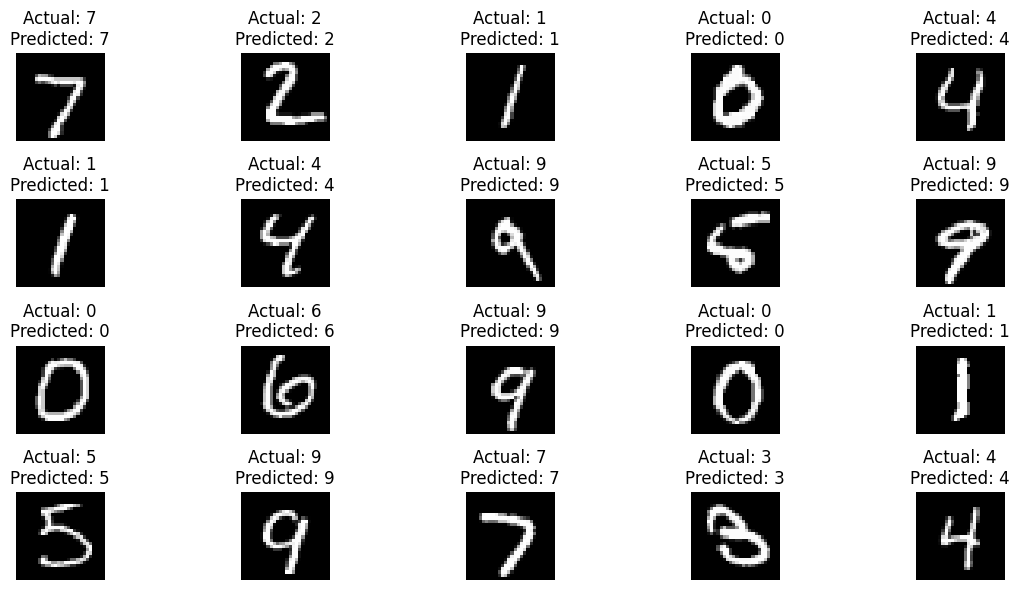

In [8]:
# ============================================================
# DISPLAY SAMPLE PREDICTIONS
# ============================================================

dropout_model.eval()

images, labels = next(iter(test_loader))

images_gpu = images.to(device)

with torch.no_grad():

    outputs = dropout_model(images_gpu)

    _, predictions = torch.max(outputs, 1)


plt.figure(figsize=(12, 6))

for i in range(20):

    plt.subplot(4, 5, i + 1)

    image = images[i].squeeze().numpy()

    # Undo normalization
    image = image * 0.3081 + 0.1307

    plt.imshow(image, cmap="gray")

    plt.title(
        f"Actual: {labels[i].item()}\n"
        f"Predicted: {predictions[i].item()}"
    )

    plt.axis("off")

plt.tight_layout()

plt.show()